In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Cargar el dataset (Asegúrate de que la ruta sea correcta o usa la URL oficial del curso)
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"
df = pd.read_csv(URL)

# Inspección rápida para asegurar que cargó bien
df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


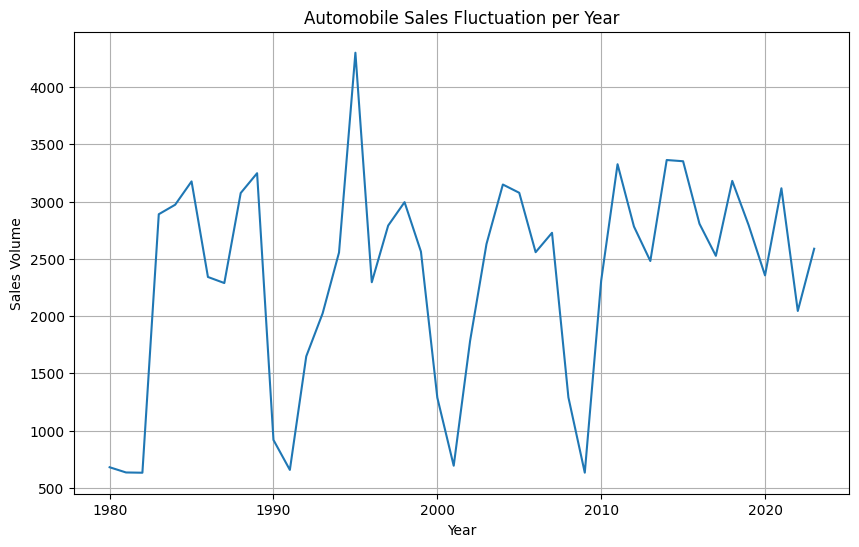

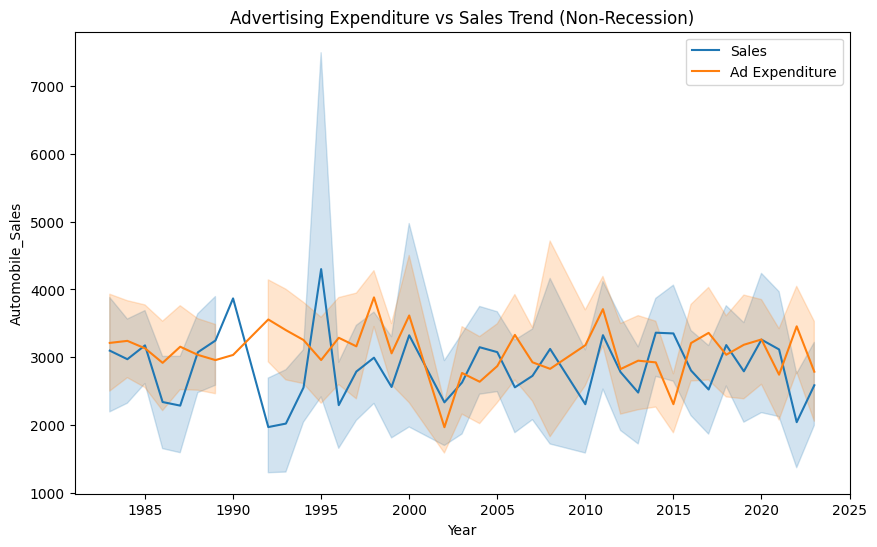

In [2]:
# 1.1: Automobile sales fluctuate from year to year
plt.figure(figsize=(10, 6))
df_line = df.groupby('Year')['Automobile_Sales'].mean()
df_line.plot(kind='line')
plt.title('Automobile Sales Fluctuation per Year')
plt.xlabel('Year')
plt.ylabel('Sales Volume')
plt.grid(True)
plt.show()

# 1.2: Advertising expenditure correlate with automobile sales (Non-Recession)
df_non_recession = df[df['Recession'] == 0]
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_non_recession, x='Year', y='Automobile_Sales', label='Sales')
sns.lineplot(data=df_non_recession, x='Year', y='Advertising_Expenditure', label='Ad Expenditure')
plt.title('Advertising Expenditure vs Sales Trend (Non-Recession)')
plt.legend()
plt.show()

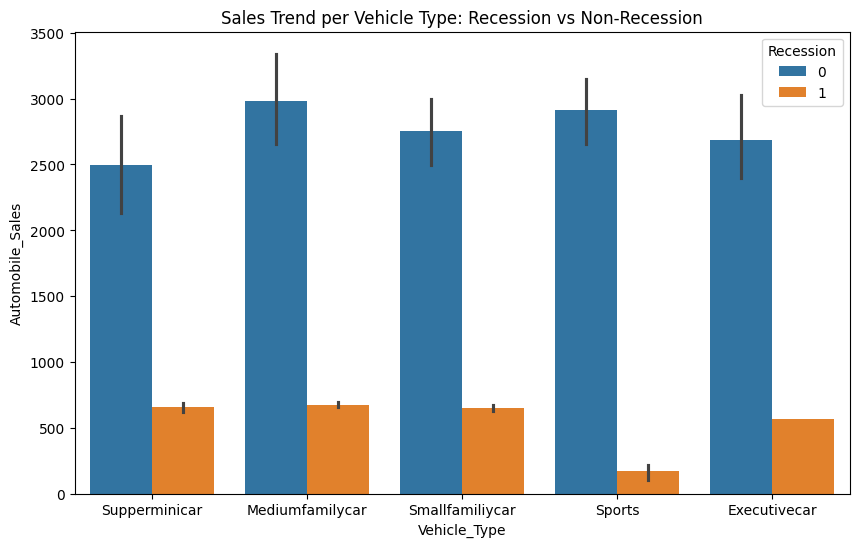

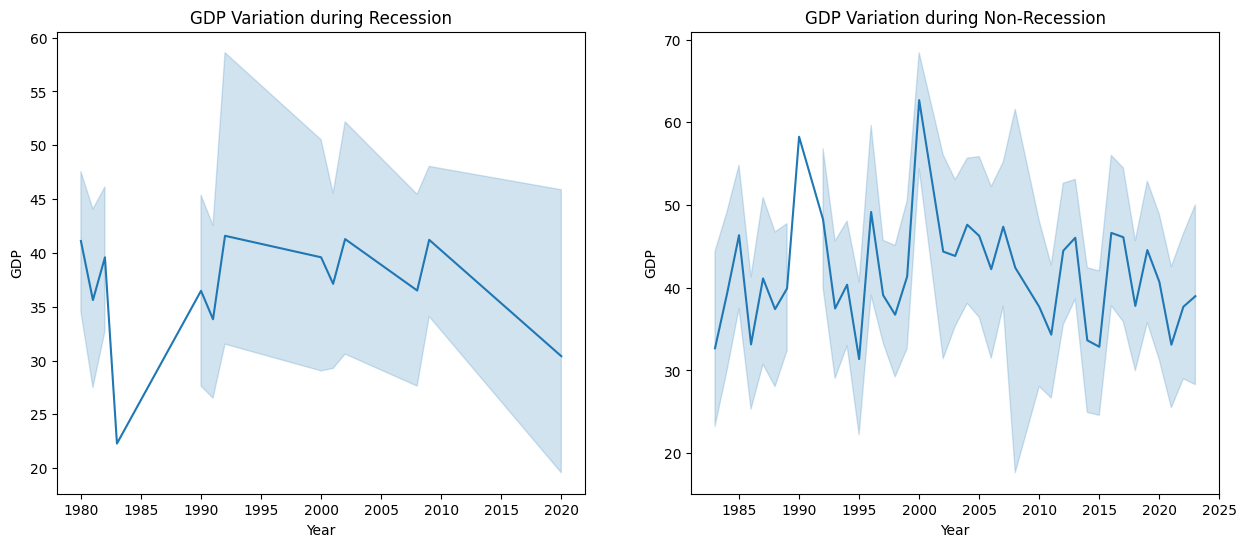

In [3]:
# 1.3: Sales trend per vehicle type (Recession vs Non-Recession)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Vehicle_Type', y='Automobile_Sales', hue='Recession')
plt.title('Sales Trend per Vehicle Type: Recession vs Non-Recession')
plt.show()

# 1.4: Subplots for GDP variations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.lineplot(data=df[df['Recession'] == 1], x='Year', y='GDP', ax=ax1)
ax1.set_title('GDP Variation during Recession')
sns.lineplot(data=df[df['Recession'] == 0], x='Year', y='GDP', ax=ax2)
ax2.set_title('GDP Variation during Non-Recession')
plt.show()

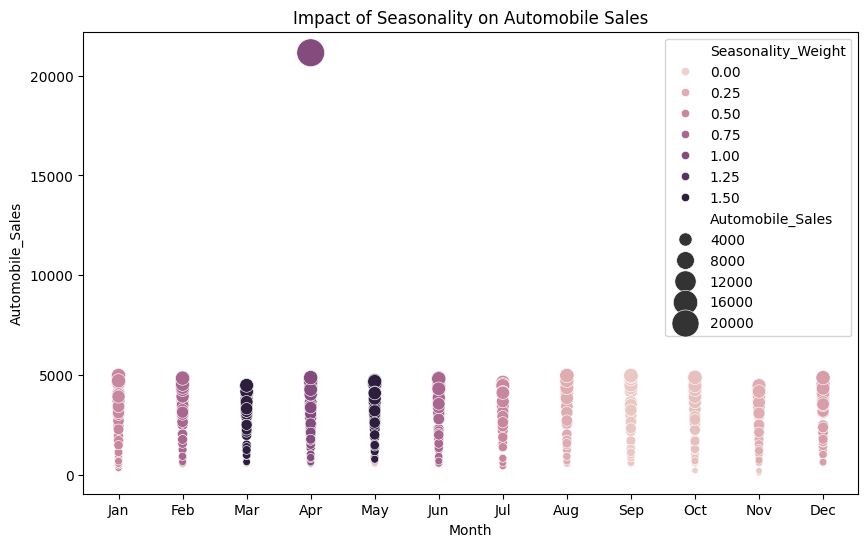

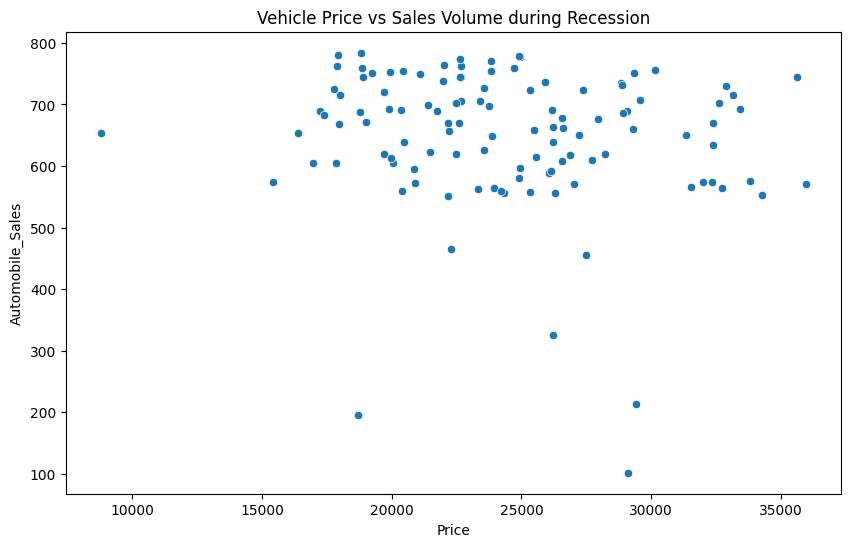

In [4]:
# 1.5: Bubble plot - Impact of seasonality
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Month', y='Automobile_Sales', size='Automobile_Sales',
                hue='Seasonality_Weight', sizes=(20, 400), legend='brief')
plt.title('Impact of Seasonality on Automobile Sales')
plt.show()

# 1.6: Scatter plot - Price vs Sales Volume (Recession Period)
df_rec = df[df['Recession'] == 1]
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_rec, x='Price', y='Automobile_Sales')
plt.title('Vehicle Price vs Sales Volume during Recession')
plt.show()

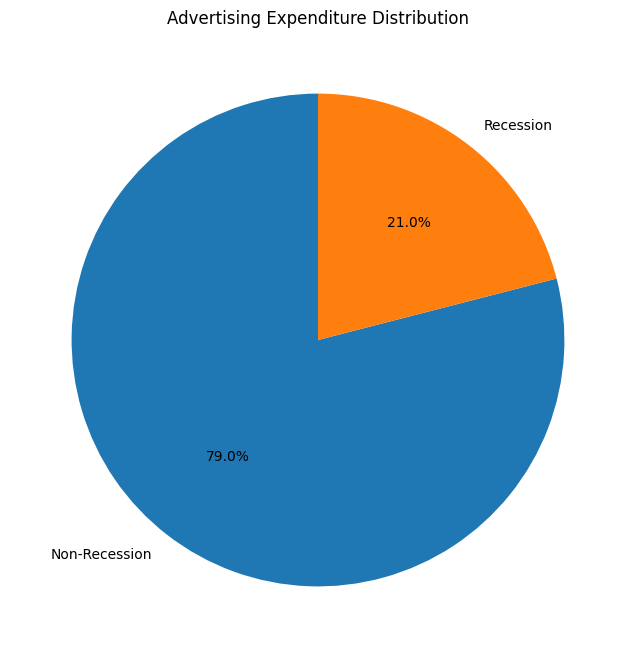

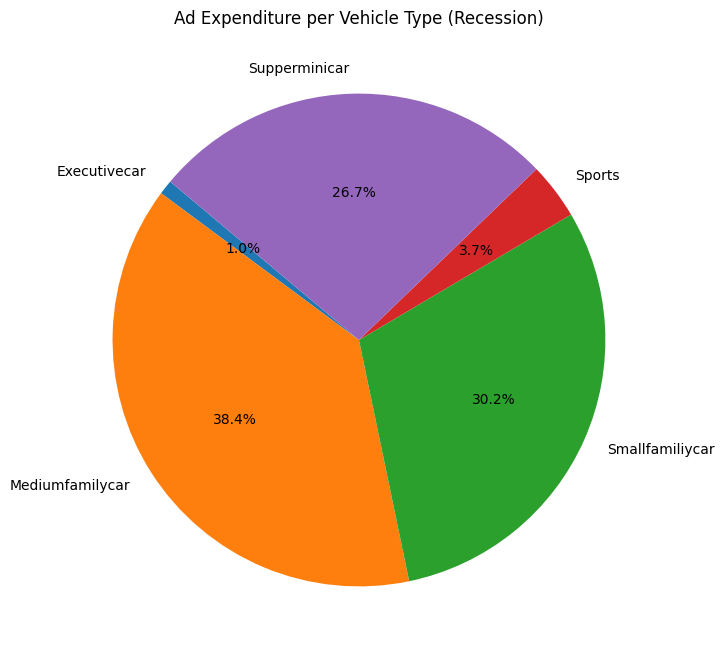

In [5]:
# 1.7: Advertising expenditure portion (Recession vs Non-recession)
ad_exp_total = df.groupby('Recession')['Advertising_Expenditure'].sum()
plt.figure(figsize=(8, 8))
plt.pie(ad_exp_total, labels=['Non-Recession', 'Recession'], autopct='%1.1f%%', startangle=90)
plt.title('Advertising Expenditure Distribution')
plt.show()

# 1.8: Total Advertisement expenditure for each vehicle type (Recession)
rec_ad_vehicle = df_rec.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
plt.figure(figsize=(8, 8))
plt.pie(rec_ad_vehicle, labels=rec_ad_vehicle.index, autopct='%1.1f%%', startangle=140)
plt.title('Ad Expenditure per Vehicle Type (Recession)')
plt.show()

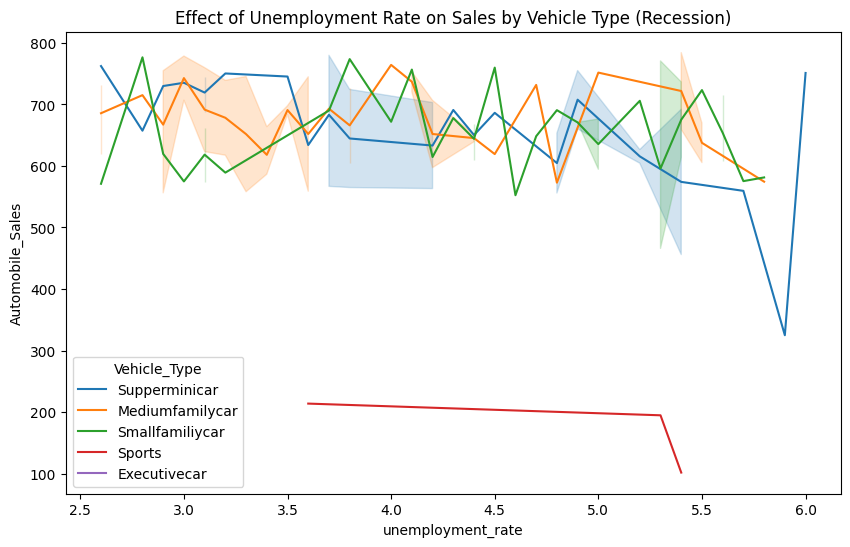

In [6]:
# 1.9: Effect of unemployment rate on vehicle type and sales (Recession)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_rec, x='unemployment_rate', y='Automobile_Sales', hue='Vehicle_Type')
plt.title('Effect of Unemployment Rate on Sales by Vehicle Type (Recession)')
plt.show()